In [5]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Step 2: Load Breast Cancer Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# Step 3: Train-Test Split and Feature Scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)
print("Feature scaling completed successfully!")

Training data shape: (455, 30)
Testing data shape: (114, 30)
Feature scaling completed successfully!


In [8]:
# Step 4: SVM with Linear Kernel

svm_linear = SVC(kernel='linear', probability=True, random_state=42)

svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
y_prob_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

print("Linear Kernel SVM trained successfully!")

Linear Kernel SVM trained successfully!


In [9]:
# Step 5: Evaluate Linear Kernel SVM

accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
auc_linear = roc_auc_score(y_test, y_prob_linear)

print("Linear Kernel SVM Results")
print("-------------------------")
print("Accuracy :", round(accuracy_linear, 4))
print("Precision:", round(precision_linear, 4))
print("Recall   :", round(recall_linear, 4))
print("AUC      :", round(auc_linear, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

Linear Kernel SVM Results
-------------------------
Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
AUC      : 0.9964

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [10]:
# Step 6: SVM with RBF Kernel

svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_prob_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

print("RBF Kernel SVM trained successfully!")

RBF Kernel SVM trained successfully!


In [11]:
# Step 7: Evaluate RBF Kernel SVM

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
auc_rbf = roc_auc_score(y_test, y_prob_rbf)

print("RBF Kernel SVM Results")
print("---------------------")
print("Accuracy :", round(accuracy_rbf, 4))
print("Precision:", round(precision_rbf, 4))
print("Recall   :", round(recall_rbf, 4))
print("AUC      :", round(auc_rbf, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

RBF Kernel SVM Results
---------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
AUC      : 0.995

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# Step 8: Compare Linear and RBF Kernels

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'AUC'],
    'Linear Kernel': [
        accuracy_linear,
        precision_linear,
        recall_linear,
        auc_linear
    ],
    'RBF Kernel': [
        accuracy_rbf,
        precision_rbf,
        recall_rbf,
        auc_rbf
    ]
})

print(comparison)

      Metric  Linear Kernel  RBF Kernel
0   Accuracy       0.973684    0.982456
1  Precision       0.985915    0.986111
2     Recall       0.972222    0.986111
3        AUC       0.996362    0.995040


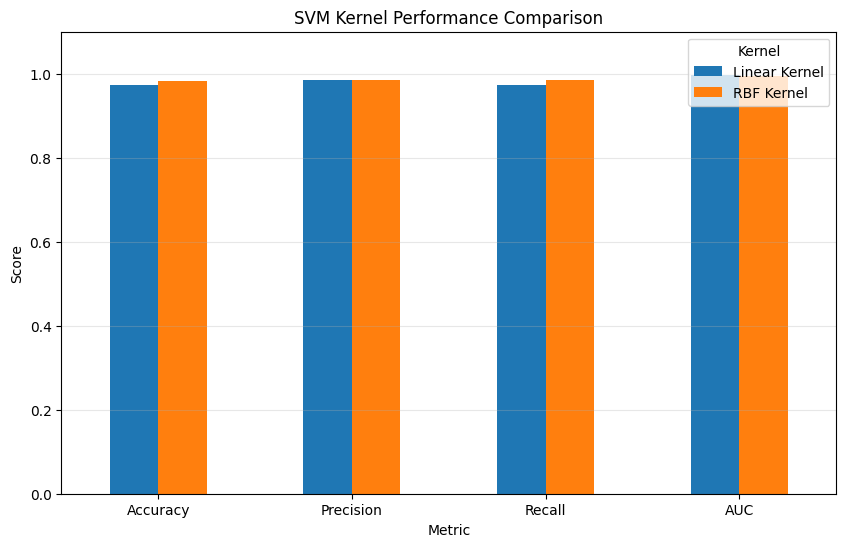

In [13]:
# Step 9: Visualize Linear vs RBF Performance

comparison_plot = comparison.set_index('Metric')

comparison_plot.plot(kind='bar', figsize=(10, 6))

plt.title('SVM Kernel Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title='Kernel')
plt.grid(axis='y', alpha=0.3)

plt.show()

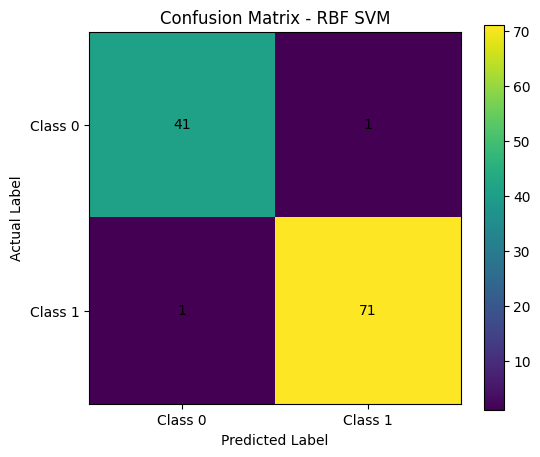

Confusion Matrix:
[[41  1]
 [ 1 71]]


In [14]:
# Step 10: Confusion Matrix for RBF SVM

cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

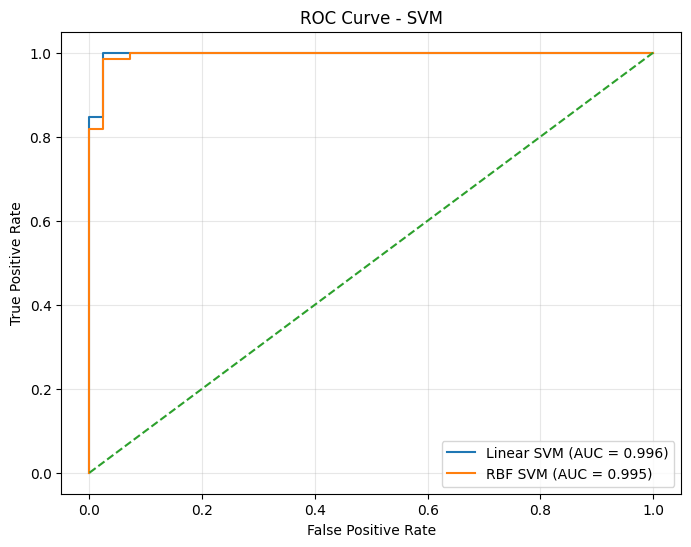

In [15]:
# Step 11: ROC Curve for Linear and RBF SVM

from sklearn.metrics import roc_curve

fpr_linear, tpr_linear, _ = roc_curve(y_test, y_prob_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_linear,
    tpr_linear,
    label=f"Linear SVM (AUC = {auc_linear:.3f})"
)

plt.plot(
    fpr_rbf,
    tpr_rbf,
    label=f"RBF SVM (AUC = {auc_rbf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [16]:
# Step 12: Final SVM Results

final_results = pd.DataFrame({
    "Kernel": ["Linear", "RBF"],
    "Accuracy": [accuracy_linear, accuracy_rbf],
    "Precision": [precision_linear, precision_rbf],
    "Recall": [recall_linear, recall_rbf],
    "AUC": [auc_linear, auc_rbf]
})

print("Final SVM Performance Comparison")
print("--------------------------------")
display(final_results.round(4))

Final SVM Performance Comparison
--------------------------------


,Kernel,Accuracy,Precision,Recall,AUC
0,Linear,0.9737,0.9859,0.9722,0.9964
1,RBF,0.9825,0.9861,0.9861,0.9950


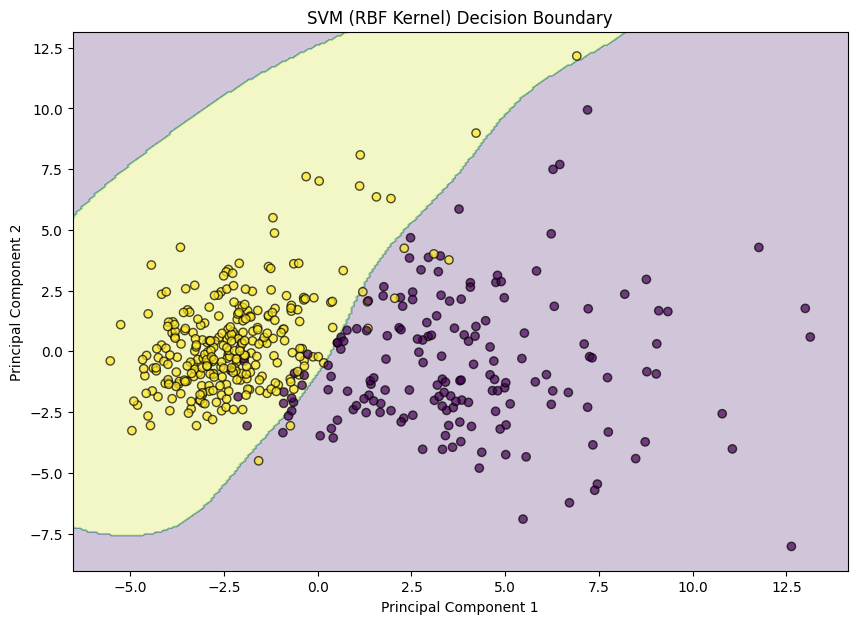

In [17]:
# Step 13: SVM Decision Boundary Visualization

from sklearn.decomposition import PCA

# Reduce features to 2 dimensions
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train RBF SVM on 2D PCA data
svm_pca = SVC(kernel='rbf', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Create mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict for every point in the grid
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    edgecolors='k',
    alpha=0.7
)

plt.title("SVM (RBF Kernel) Decision Boundary")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [18]:
# Step 14: Final Task Summary

print("LEVEL 3 - TASK 2: SVM CLASSIFICATION")
print("=" * 45)

print("\nKernels Compared:")
print("1. Linear Kernel")
print("2. RBF Kernel")

print("\nLinear Kernel:")
print("Accuracy :", round(accuracy_linear, 4))
print("Precision:", round(precision_linear, 4))
print("Recall   :", round(recall_linear, 4))
print("AUC      :", round(auc_linear, 4))

print("\nRBF Kernel:")
print("Accuracy :", round(accuracy_rbf, 4))
print("Precision:", round(precision_rbf, 4))
print("Recall   :", round(recall_rbf, 4))
print("AUC      :", round(auc_rbf, 4))

print("\nDecision boundary visualization: Completed")

LEVEL 3 - TASK 2: SVM CLASSIFICATION

Kernels Compared:
1. Linear Kernel
2. RBF Kernel

Linear Kernel:
Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
AUC      : 0.9964

RBF Kernel:
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
AUC      : 0.995

Decision boundary visualization: Completed
